# CS 5542 Quiz Challenge 1 - E-Commerce Image Generation (Colab Execution)
**Author**: Tina Nguyen

This notebook executes the full End-to-End Stable Diffusion pipeline. It is configured to run automatically using a Colab T4/L4 GPU. It generates exactly 10 products * 3 seeds (30 baseline + 30 structured images) and formally evaluates their consistency (SSIM) and alignment (CLIP).

## 1. Environment Setup

In [ ]:
# Clone the GitHub repository to load the pipeline code and dataset
!git clone https://github.com/tinana2k/Comp-Sci-5542-Tina-Nguyen.git
%cd QuizzTN


Cloning into 'QuizzTN'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 44 (delta 11), reused 44 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 7.38 MiB | 32.44 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/QuizzTN


In [2]:
# Install all the necessary dependencies for Stable Diffusion and Evaluation
!pip install -q diffusers transformers accelerate safetensors openai-clip scikit-image
!nvidia-smi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
Mon Apr 20 05:34:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             44W 

## 2. Generate Images (Full Pipeline)
This will run our generator script and process all defined products across 3 different seeds.

In [3]:
!python src/generator.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading model stabilityai/stable-diffusion-xl-base-1.0 on cuda...
model_index.json: 100% 609/609 [00:00<00:00, 3.63MB/s]
Fetching 19 files:   0% 0/19 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching 19 files: 100% 19/19 [00:17<00:00,  1.10it/s]
Download complete: : 7.11GB [00:17, 369MB/s]              
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading pipeline components...:  14% 1/7 [00:00<00:00,  8.99it/s]
Download complete: : 7.11GB [00:17, 404MB/s]
Loading weights: 100% 196/196 [00:00<00:00, 1037.08it/s, Materializing param=text_model.final_layer_norm.weight]

L

## 3. Quantitative Evaluation (CLIP & SSIM)
Now we run the evaluator module. This mathematically measures Text-to-Image alignment and Cross-seed structural consistency.

In [4]:
!python src/evaluator.py

Loading CLIP model on cuda...
config.json: 4.19kB [00:00, 12.1MB/s]
pytorch_model.bin: 100% 605M/605M [00:02<00:00, 215MB/s]
model.safetensors:   0% 0.00/605M [00:00<?, ?B/s]
Loading weights:   0% 0/398 [00:00<?, ?it/s]
Loading weights:   0% 1/398 [00:00<00:00, 8050.49it/s, Materializing param=logit_scale]
Loading weights:   0% 1/398 [00:00<00:00, 1834.78it/s, Materializing param=logit_scale]
Loading weights:   1% 2/398 [00:00<00:00, 1965.01it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 2/398 [00:00<00:00, 837.35it/s, Materializing param=text_model.embeddings.position_embedding.weight] 
Loading weights:   1% 3/398 [00:00<00:00, 950.37it/s, Materializing param=text_model.embeddings.token_embedding.weight]   
Loading weights:   1% 3/398 [00:00<00:00, 764.45it/s, Materializing param=text_model.embeddings.token_embedding.weight]
Loading weights:   1% 4/398 [00:00<00:00, 736.91it/s, Materializing param=text_model.encoder.layers.0.layer_norm1

## 4. Visual Result Summary
We render the evaluation summary matrix generated from the `quantitative_results.json` file.

In [5]:
import json
import pandas as pd
from IPython.display import display

try:
    with open("evaluation/quantitative_results.json", "r") as f:
        results = json.load(f)
    df = pd.DataFrame(results)

    print("--- EVALUATION AVERAGES ---")
    print(f"Baseline CLIP: {df['baseline_clip'].mean():.3f} -> Improved CLIP: {df['improved_clip'].mean():.3f}")
    print(f"Baseline SSIM: {df['baseline_ssim'].mean():.3f} -> Improved SSIM: {df['improved_ssim'].mean():.3f}")
    print("""
--- DETAILED METRICS ---""")
    display(df)
except Exception as e:
    print("Could not load results. Did you run the evaluator cell above? Error:", e)

--- EVALUATION AVERAGES ---
Baseline CLIP: 0.288 -> Improved CLIP: 0.279
Baseline SSIM: 0.360 -> Improved SSIM: 0.442

--- DETAILED METRICS ---


,product_id,title,baseline_clip,improved_clip,baseline_ssim,improved_ssim
0,1,Women Summer Dress,0.248597,0.252488,0.262442,0.344327
1,2,Running Shoes,0.283147,0.227342,0.099913,0.176511
2,3,Coffee Mug,0.315064,0.300890,0.459756,0.731994
3,4,Leather Backpack,0.304516,0.301164,0.614062,0.257768
4,5,Wrist Watch,0.267542,0.278839,0.088031,0.190892
5,6,Hoodie,0.301841,0.301361,0.413782,0.421019
6,7,Sneakers,0.294015,0.259978,0.170019,0.349175
7,8,Handbag,0.289122,0.278583,0.421620,0.539744
8,9,Smart Speaker,0.272043,0.284252,0.498254,0.716112
9,10,Wireless Earbuds,0.307139,0.305848,0.569768,0.691463


## 5. View Comparison Charts
Display the generated comparison images and seed consistency visuals.

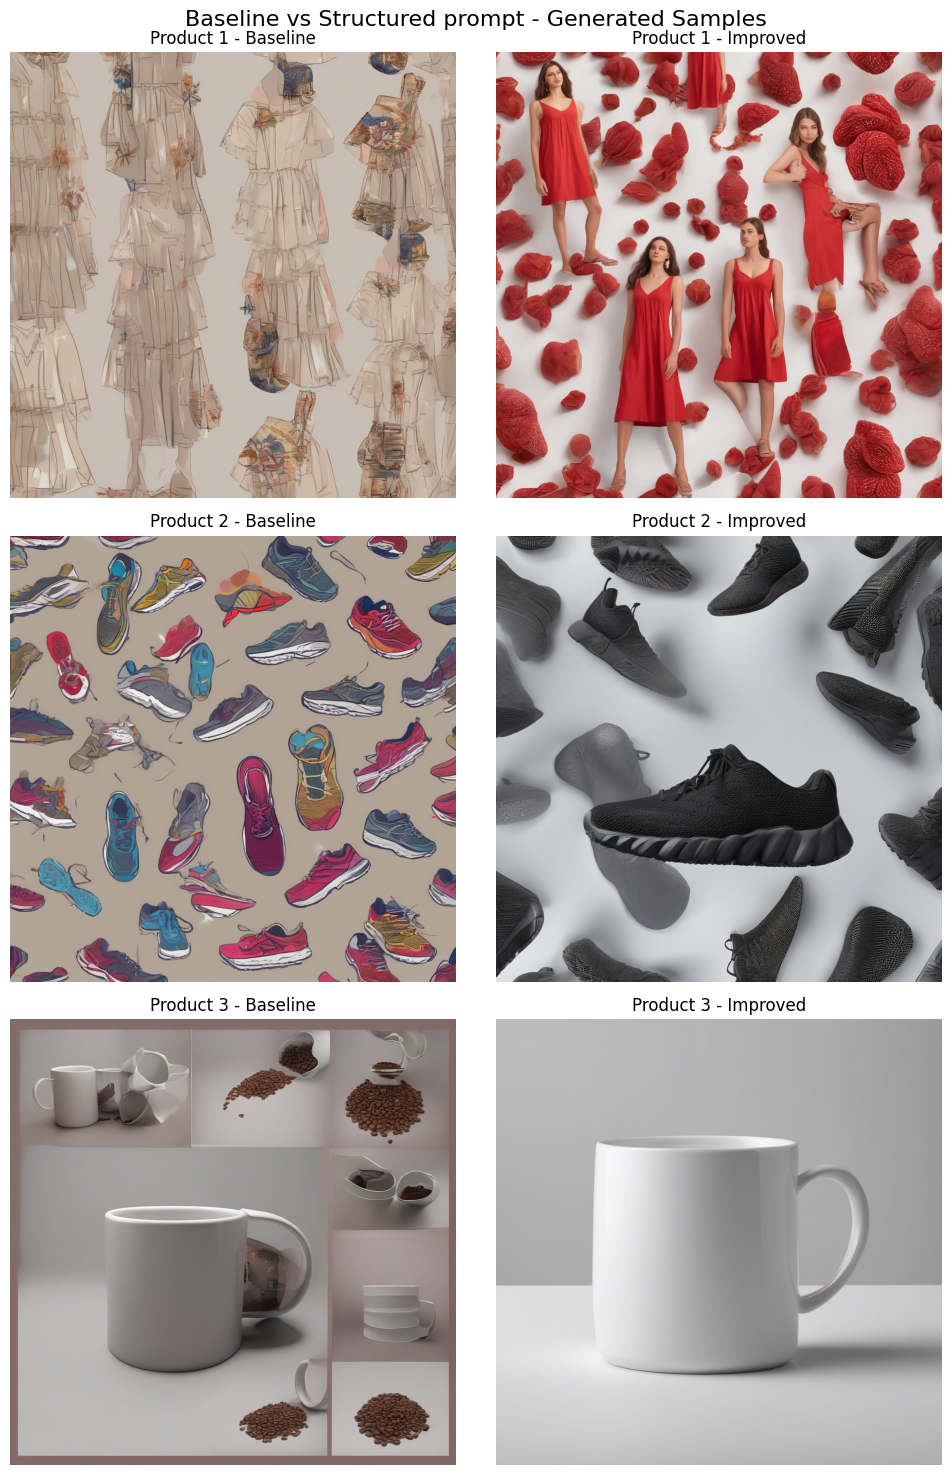

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image

try:
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))
    fig.suptitle("Baseline vs Structured prompt - Generated Samples", fontsize=16)

    # Show the first 3 products
    for i, p_id in enumerate([1, 2, 3]):
        # Use seed 42 as representative
        base_img = f"outputs/baseline/prod_{p_id}_baseline_seed42.png"
        imp_img = f"outputs/improved/prod_{p_id}_improved_seed42.png"

        if os.path.exists(base_img) and os.path.exists(imp_img):
            axes[i, 0].imshow(Image.open(base_img))
            axes[i, 0].set_title(f"Product {p_id} - Baseline")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(Image.open(imp_img))
            axes[i, 1].set_title(f"Product {p_id} - Improved")
            axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Could not render images. Error:", e)


In [ ]:
%cd /content/QuizzTN

# 1. Configure your Git Identity
!git config --global user.email "@umsystem.edu"
!git config --global user.name "Tina"

# 2. Add and commit all changes (outputs and any manually replaced notebooks)
!git add .
!git commit -m "Add generated images, evaluation results, and updated notebook"

# 3. Push to GitHub
!git push main

print('☑️ Git commit and push executed.')

/content/QuizzTN
[main a4e6472] Add generated images, evaluation results, and updated notebook
 62 files changed, 98 insertions(+), 40 deletions(-)
 create mode 100644 evaluation/quantitative_results.json
 rewrite evaluation/results.md (99%)
 create mode 100644 outputs/baseline/prod_10_baseline_seed123.png
 create mode 100644 outputs/baseline/prod_10_baseline_seed42.png
 create mode 100644 outputs/baseline/prod_10_baseline_seed999.png
 create mode 100644 outputs/baseline/prod_1_baseline_seed123.png
 create mode 100644 outputs/baseline/prod_1_baseline_seed42.png
 create mode 100644 outputs/baseline/prod_1_baseline_seed999.png
 create mode 100644 outputs/baseline/prod_2_baseline_seed123.png
 create mode 100644 outputs/baseline/prod_2_baseline_seed42.png
 create mode 100644 outputs/baseline/prod_2_baseline_seed999.png
 create mode 100644 outputs/baseline/prod_3_baseline_seed123.png
 create mode 100644 outputs/baseline/prod_3_baseline_seed42.png
 create mode 100644 outputs/baseline/prod_3_